# Train Classifiers Notebook

Этот ноутбук воспроизводит `datasetCreation/train_classifiers.py` как серию блоков.
После выполнения обучения добавлен подробный расчет метрик, включая F1, recall, precision, ROC AUC и другие полезные показатели.

In [2]:
import argparse
import json
import random
import shutil
import sys
import tempfile
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from ultralytics import YOLO

project_root = Path.cwd()
if not (project_root / "pipeline").exists() and (project_root.parent / "pipeline").exists():
    project_root = project_root.parent
sys.path.append(str(project_root))

from pipeline.classifier_models import (
    CLASS_NAMES,
    IMAGENET_MEAN,
    IMAGENET_STD,
    MODEL_INPUT_SIZE,
    SUPPORTED_MODELS,
    create_classifier,
)

DEFAULT_OUTPUT_DIR = Path("artifacts/classification")
DEFAULT_DATASET_ROOT = Path("datasetCreation/cropped_datumaro")

In [5]:
class CropDataset(Dataset):
    def __init__(self, image_paths, labels, transform):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        image = Image.open(self.image_paths[index]).convert("RGB")
        return self.transform(image), self.labels[index]

def parse_args():
    parser = argparse.ArgumentParser(description="Train multiple classifiers on cropped KGO dataset.")
    parser.add_argument("--dataset-root", type=Path, default=DEFAULT_DATASET_ROOT)
    parser.add_argument("--output-dir", type=Path, default=DEFAULT_OUTPUT_DIR)
    parser.add_argument("--models", nargs="+", default=list(SUPPORTED_MODELS), choices=SUPPORTED_MODELS, help="Models to train. По умолчанию обучаются все поддерживаемые модели.")
    parser.add_argument("--epochs", type=int, default=30)
    parser.add_argument("--batch-size", type=int, default=16)
    parser.add_argument("--learning-rate", type=float, default=1e-4)
    parser.add_argument("--weight-decay", type=float, default=1e-5)
    parser.add_argument("--num-workers", type=int, default=0)
    parser.add_argument("--early-stop-patience", type=int, default=4)
    parser.add_argument("--seed", type=int, default=42)
    parser.add_argument("--no-pretrained", action="store_true")
    return parser.parse_args()

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def build_transforms():
    train_transform = transforms.Compose([
        transforms.Resize((MODEL_INPUT_SIZE, MODEL_INPUT_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])
    eval_transform = transforms.Compose([
        transforms.Resize((MODEL_INPUT_SIZE, MODEL_INPUT_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])
    return train_transform, eval_transform

def collect_samples(dataset_root: Path):
    samples = [(image_path, label_index) for label_index, class_name in enumerate(CLASS_NAMES) for image_path in sorted((dataset_root / class_name).glob("*.jpg"))]
    if not samples:
        raise RuntimeError(f"No .jpg files found in {dataset_root}")
    image_paths, labels = zip(*samples)
    return list(image_paths), list(labels)

def split_samples(image_paths, labels, seed: int):
    train_paths, temp_paths, train_labels, temp_labels = train_test_split(
        image_paths,
        labels,
        test_size=0.30,
        random_state=seed,
        stratify=labels,
    )
    val_paths, test_paths, val_labels, test_labels = train_test_split(
        temp_paths,
        temp_labels,
        test_size=0.50,
        random_state=seed,
        stratify=temp_labels,
    )
    return {
        "train": (train_paths, train_labels),
        "val": (val_paths, val_labels),
        "test": (test_paths, test_labels),
    }

def prepare_yolo_dataset(splits, temp_root: Path):
    for split_name in ("train", "val", "test"):
        for image_path, label in zip(*splits[split_name]):
            dest_dir = temp_root / split_name / CLASS_NAMES[label]
            dest_dir.mkdir(parents=True, exist_ok=True)
            shutil.copy2(image_path, dest_dir / image_path.name)

def build_yolo_data_yaml(temp_root: Path):
    yaml_lines = [
        f"path: {temp_root}",
        "train: train",
        "val: val",
        "test: test",
        "names:",
    ]
    yaml_lines.extend(f"  {idx}: {name}" for idx, name in enumerate(CLASS_NAMES))
    data_yaml_path = temp_root / "dataset.yaml"
    data_yaml_path.write_text("\n".join(yaml_lines), encoding="utf-8")
    return data_yaml_path

def train_yolo_classifier(splits, args, device):
    if args.no_pretrained:
        print("[yolo] Warning: YOLO classification uses yolov8n-cls.pt pretrained weights by default.")

    with tempfile.TemporaryDirectory() as tmpdir:
        temp_root = Path(tmpdir)
        prepare_yolo_dataset(splits, temp_root)
        data_yaml_path = build_yolo_data_yaml(temp_root)

        yolo_model = YOLO("yolov8n-cls.pt")
        yolo_model.train(
            data=str(data_yaml_path),
            epochs=args.epochs,
            batch=args.batch_size,
            imgsz=MODEL_INPUT_SIZE,
            workers=args.num_workers,
            lr0=args.learning_rate,
            device=str(device),
            project=str(temp_root),
            name="yolo_classifier",
            exist_ok=True,
        )

        weights_dir = temp_root / "yolo_classifier" / "weights"
        best_weights = weights_dir / "best.pt"
        if not best_weights.exists():
            best_weights = weights_dir / "last.pt"

        trained_model = YOLO(str(best_weights))
        state_dict = trained_model.model.state_dict()

    return {
        "model_name": "yolo",
        "best_epoch": args.epochs,
        "best_val": {"loss": float("inf"), "macro_f1": 0.0},
        "test": {"loss": None, "accuracy": None, "macro_f1": None, "roc_auc": None},
        "state_dict": state_dict,
    }

def create_dataloaders(splits, batch_size: int, num_workers: int):
    train_transform, eval_transform = build_transforms()
    return {
        split_name: DataLoader(
            CropDataset(paths, labels, train_transform if split_name == "train" else eval_transform),
            batch_size=batch_size,
            shuffle=split_name == "train",
            num_workers=num_workers,
            pin_memory=True,
        )
        for split_name, (paths, labels) in splits.items()
    }

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            probs = torch.softmax(outputs, dim=1)
            preds = outputs.argmax(dim=1)

            total_loss += loss.item() * images.size(0)
            all_labels.extend(labels.cpu().numpy().tolist())
            all_preds.extend(preds.cpu().numpy().tolist())
            all_probs.extend(probs[:, 1].cpu().numpy().tolist())

    average_loss = total_loss / len(dataloader.dataset)
    metrics = {
        "loss": average_loss,
        "accuracy": accuracy_score(all_labels, all_preds),
        "macro_f1": f1_score(all_labels, all_preds, average="macro", zero_division=0),
        "roc_auc": roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else None,
    }
    return metrics

def train_model(model_name, dataloaders, args, device, splits):
    if model_name == "yolo":
        return train_yolo_classifier(splits, args, device)

    model = create_classifier(model_name, num_classes=len(CLASS_NAMES), pretrained=not args.no_pretrained).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=args.learning_rate, weight_decay=args.weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)
    scaler = torch.amp.GradScaler("cuda", enabled=device.type == "cuda")

    best_state = None
    best_metrics = None
    best_epoch = -1
    stale_epochs = 0

    for epoch in range(1, args.epochs + 1):
        model.train()
        train_loss = 0.0
        train_labels = []
        train_preds = []

        for images, labels in dataloaders["train"]:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast("cuda", enabled=device.type == "cuda"):
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item() * images.size(0)
            train_labels.extend(labels.detach().cpu().numpy().tolist())
            train_preds.extend(outputs.argmax(dim=1).detach().cpu().numpy().tolist())

        train_metrics = {
            "loss": train_loss / len(dataloaders["train"].dataset),
            "accuracy": accuracy_score(train_labels, train_preds),
            "macro_f1": f1_score(train_labels, train_preds, average="macro", zero_division=0),
        }
        val_metrics = evaluate(model, dataloaders["val"], criterion, device)
        scheduler.step(val_metrics["loss"])

        is_better = (
            best_metrics is None
            or val_metrics["macro_f1"] > best_metrics["macro_f1"]
            or (
                val_metrics["macro_f1"] == best_metrics["macro_f1"]
                and val_metrics["loss"] < best_metrics["loss"]
            )
        )

        print(
            f"[{model_name}] epoch {epoch:02d}/{args.epochs} "
            f"train_loss={train_metrics['loss']:.4f} train_f1={train_metrics['macro_f1']:.4f} "
            f"val_loss={val_metrics['loss']:.4f} val_f1={val_metrics['macro_f1']:.4f}"
        )

        if is_better:
            best_state = {key: value.detach().cpu() for key, value in model.state_dict().items()}
            best_metrics = val_metrics
            best_epoch = epoch
            stale_epochs = 0
        else:
            stale_epochs += 1
            if stale_epochs >= args.early_stop_patience:
                break

    model.load_state_dict(best_state)
    return {
        "model_name": model_name,
        "best_epoch": best_epoch,
        "best_val": best_metrics,
        "test": evaluate(model, dataloaders["test"], criterion, device),
        "state_dict": best_state,
    }

def save_result(result, output_dir: Path, split_sizes, seed: int):
    torch.save({
        "model_name": result["model_name"],
        "class_names": CLASS_NAMES,
        "input_size": MODEL_INPUT_SIZE,
        "state_dict": result["state_dict"],
    },
    output_dir / f"best_{result['model_name']}_kgo.pth")

    (output_dir / f"metrics_{result['model_name']}.json").write_text(
        json.dumps({
            "model_name": result["model_name"],
            "best_epoch": result["best_epoch"],
            "best_val": result["best_val"],
            "test": result["test"],
            "split_sizes": split_sizes,
            "seed": seed,
        }, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )

def save_leaderboard(results, output_dir: Path):
    leaderboard = sorted((
        {
            "model_name": result["model_name"],
            "best_epoch": result["best_epoch"],
            "val_macro_f1": result["best_val"]["macro_f1"],
            "val_loss": result["best_val"]["loss"],
            "test_macro_f1": result["test"]["macro_f1"],
            "test_accuracy": result["test"]["accuracy"],
            "test_roc_auc": result["test"]["roc_auc"],
        }
        for result in results
    ), key=lambda item: (-item["val_macro_f1"], item["val_loss"]))
    (output_dir / "leaderboard.json").write_text(
        json.dumps(leaderboard, ensure_ascii=False, indent=2),

        encoding="utf-8",    )

In [7]:
from argparse import Namespace

args = Namespace(
    dataset_root=DEFAULT_DATASET_ROOT,
    output_dir=DEFAULT_OUTPUT_DIR,
    models=list(SUPPORTED_MODELS),
    epochs=30,
    batch_size=16,
    learning_rate=1e-4,
    weight_decay=1e-5,
    num_workers=0,
    early_stop_patience=4,
    seed=42,
    no_pretrained=False,
)

set_seed(args.seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if not args.dataset_root.exists():
    raise FileNotFoundError(
        f"Dataset root not found: {args.dataset_root}. Run datasetCreation/prepare_datumaro_dataset.py first."
    )

Using device: cuda


In [9]:
image_paths, labels = collect_samples(args.dataset_root)
splits = split_samples(image_paths, labels, seed=args.seed)
split_sizes = {split_name: len(paths) for split_name, (paths, _) in splits.items()}
dataloaders = create_dataloaders(splits, batch_size=args.batch_size, num_workers=args.num_workers)
args.output_dir.mkdir(parents=True, exist_ok=True)
print("Split sizes:", split_sizes)

results = []
for model_name in args.models:
    started_at = time.time()
    result = train_model(model_name, dataloaders, args, device, splits)
    result["elapsed_seconds"] = round(time.time() - started_at, 2)
    save_result(result, args.output_dir, split_sizes, args.seed)
    results.append(result)
    print(
        f"[{model_name}] done in {result['elapsed_seconds']}s "
        f"test_f1={result['test']['macro_f1']:.4f} test_acc={result['test']['accuracy']:.4f}"
    )

save_leaderboard(results, args.output_dir)
print(f"Saved checkpoints and metrics to {args.output_dir}")

Split sizes: {'train': 2999, 'val': 643, 'test': 643}
[resnet18] epoch 01/30 \, train_loss=0.2788 train_f1=0.8736 \ , val_loss=0.1826 val_f1=0.9240
[resnet18] epoch 02/30 \, train_loss=0.1858 train_f1=0.9192 \ , val_loss=0.2192 val_f1=0.9210
[resnet18] epoch 03/30 \, train_loss=0.1475 train_f1=0.9366 \ , val_loss=0.2274 val_f1=0.9117
[resnet18] epoch 04/30 \, train_loss=0.1252 train_f1=0.9461 \ , val_loss=0.1779 val_f1=0.9077
[resnet18] epoch 05/30 \, train_loss=0.0937 train_f1=0.9626 \ , val_loss=0.2934 val_f1=0.9133
[resnet18] done in 171.62s \, test_f1=0.8990 test_acc=0.9036
[resnet34] epoch 01/30 \, train_loss=0.2957 train_f1=0.8705 \ , val_loss=0.3352 val_f1=0.8747
[resnet34] epoch 02/30 \, train_loss=0.1864 train_f1=0.9186 \ , val_loss=0.2391 val_f1=0.9038
[resnet34] epoch 03/30 \, train_loss=0.1641 train_f1=0.9283 \ , val_loss=0.2273 val_f1=0.8992
[resnet34] epoch 04/30 \, train_loss=0.1263 train_f1=0.9498 \ , val_loss=0.2239 val_f1=0.9145
[resnet34] epoch 05/30 \, train_loss=0.

RuntimeError: Dataset 'C://Users/8523~1/AppData/Local/Temp/tmp1wuwf0uo/dataset.yaml' error  Classification datasets must be a directory (data="path/to/dir") not a file (data="C:\Users\8523~1\AppData\Local\Temp\tmp1wuwf0uo\dataset.yaml"), See https://docs.ultralytics.com/datasets/classify/

,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,balanced_accuracy,roc_auc,average_precision
model_name,,,,,,,,,,
convnext_tiny,0.925350,0.917523,0.928724,0.922117,0.928171,0.925350,0.925843,0.928724,0.980863,0.966903
efficientnet_v2_s,0.909798,0.901231,0.914583,0.906255,0.914298,0.909798,0.910535,0.914583,0.974693,0.954047
resnet18,0.903577,0.895591,0.903361,0.898992,0.905395,0.903577,0.904046,0.903361,0.961838,0.935699
resnet34,0.897356,0.888583,0.903734,0.893716,0.903810,0.897356,0.898335,0.903734,0.969144,0.947375
resnet50,0.895801,0.886945,0.898609,0.891501,0.899681,0.895801,0.896574,0.898609,0.961889,0.936386


C:\Users\Александр\AppData\Local\Temp\ipykernel_8996\3177065052.py:122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=values.index, y=values.values, palette="viridis", ax=ax)
C:\Users\Александр\AppData\Local\Temp\ipykernel_8996\3177065052.py:122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=values.index, y=values.values, palette="viridis", ax=ax)
C:\Users\Александр\AppData\Local\Temp\ipykernel_8996\3177065052.py:122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=values.index, y=values.values, palette="viridis", ax=ax)
C:\Users\Алексан

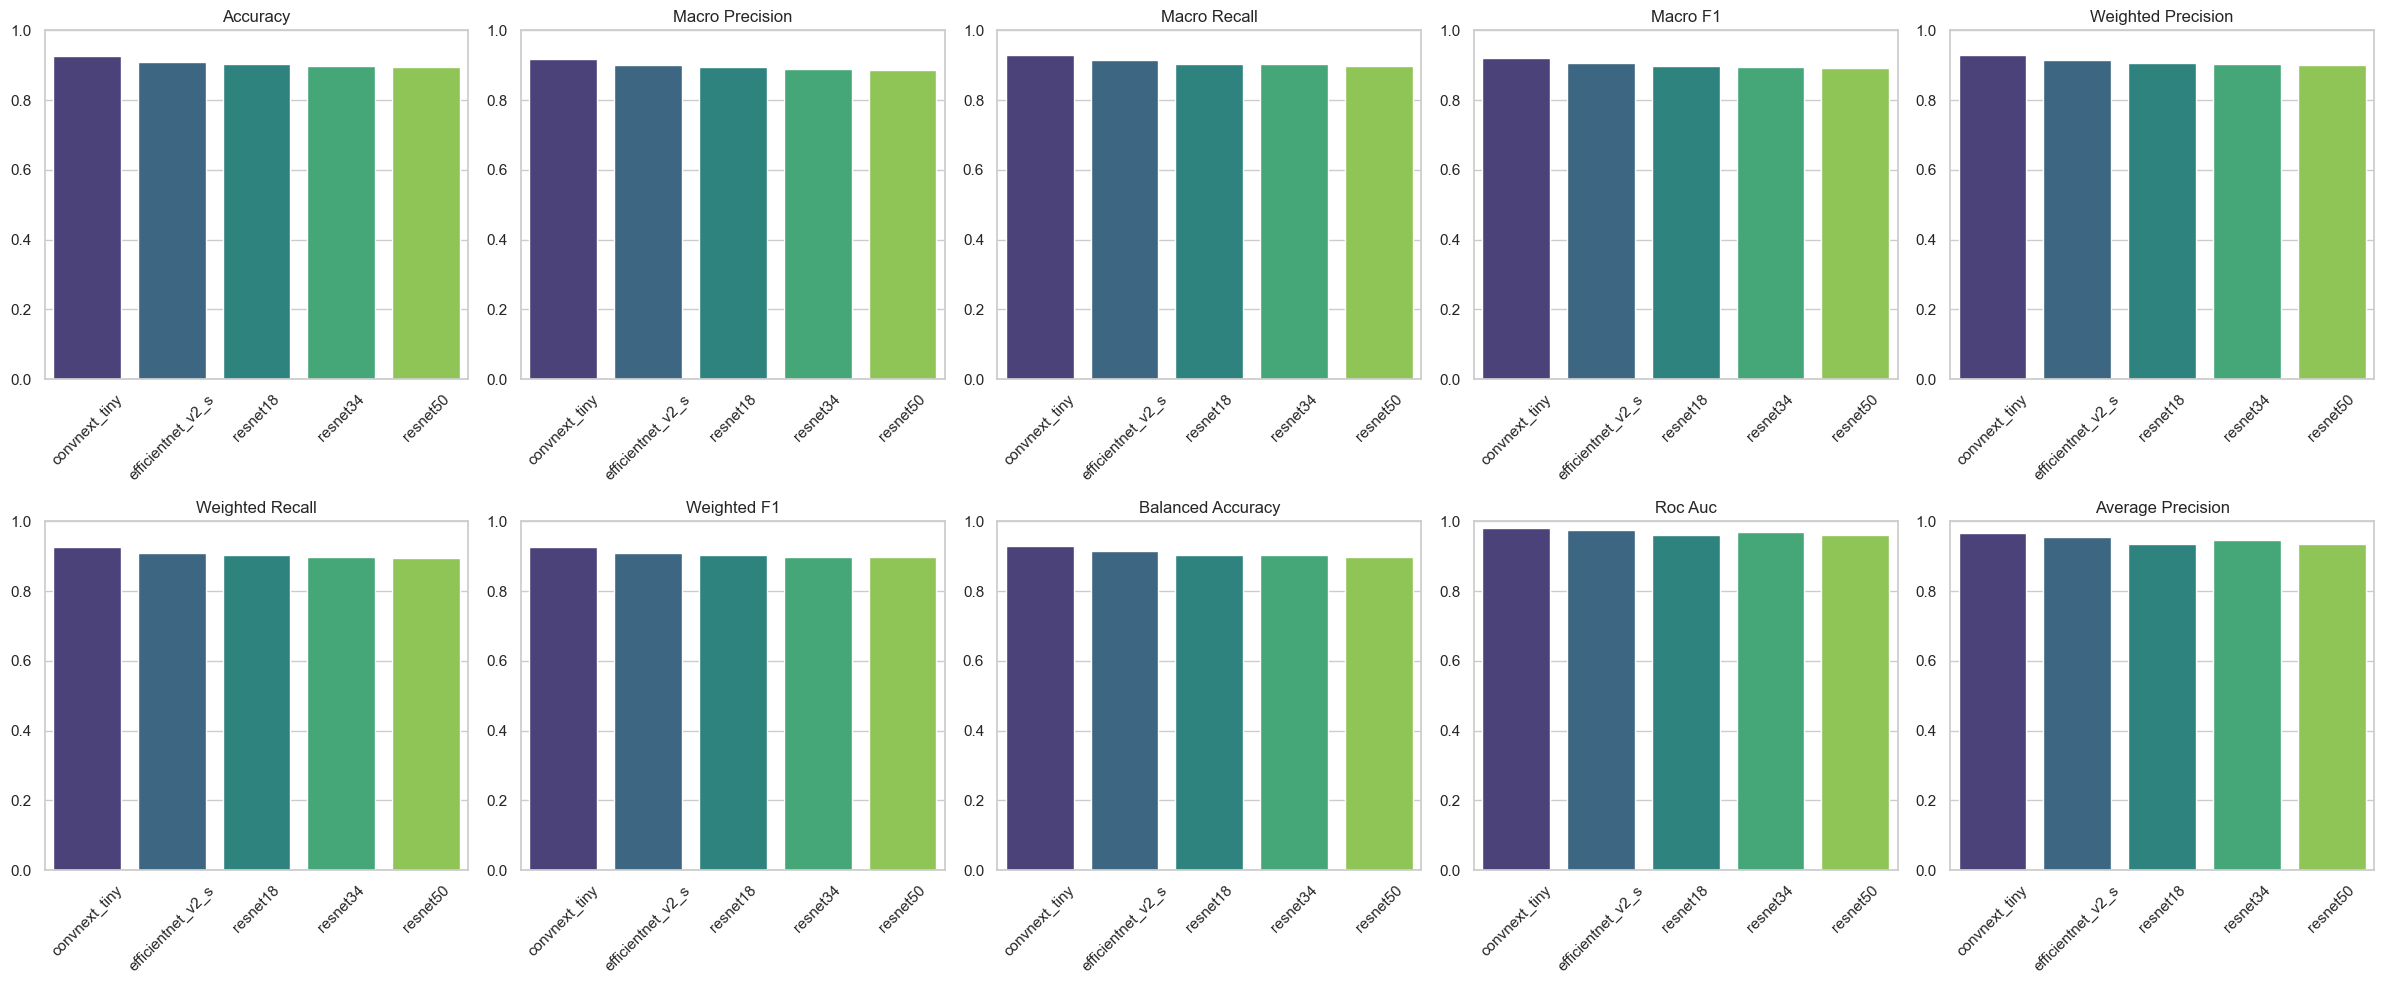

,model,class,precision,recall,f1_score,support
0,resnet18,kgo_empty,0.9373,0.9043,0.9205,397.0
1,resnet18,kgo_full,0.8538,0.9024,0.8775,246.0
2,resnet34,kgo_empty,0.9534,0.8766,0.9134,397.0
3,resnet34,kgo_full,0.8237,0.9309,0.8740,246.0
4,resnet50,kgo_empty,0.9412,0.8866,0.9131,397.0
5,resnet50,kgo_full,0.8327,0.9106,0.8699,246.0
6,efficientnet_v2_s,kgo_empty,0.9569,0.8942,0.9245,397.0
7,efficientnet_v2_s,kgo_full,0.8456,0.9350,0.8880,246.0
8,convnext_tiny,kgo_empty,0.9629,0.9144,0.9380,397.0
9,convnext_tiny,kgo_full,0.8722,0.9431,0.9062,246.0


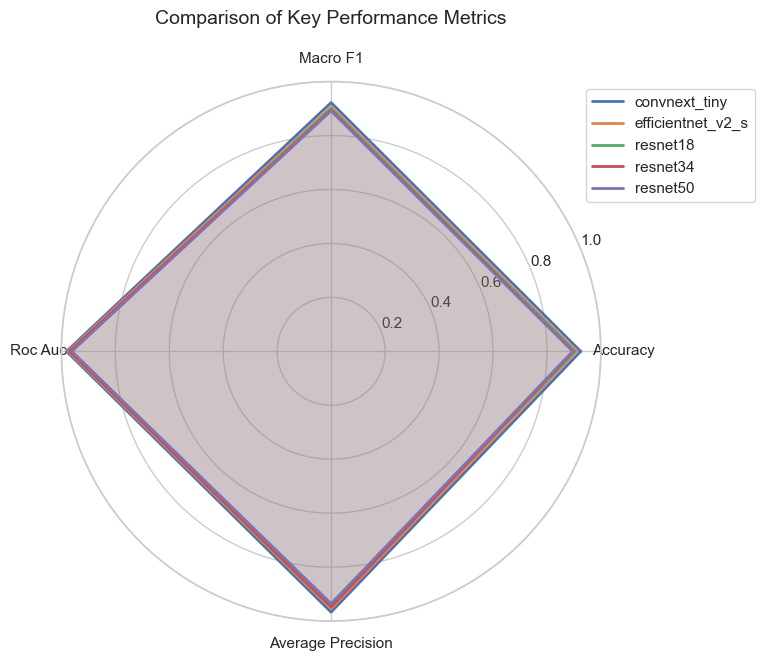

In [16]:
from sklearn.metrics import (
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    precision_score,
    recall_score,
    average_precision_score,
    roc_curve,
)
from math import pi

def collect_predictions(model, dataloader, device):
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = outputs.argmax(dim=1)

            all_labels.extend(labels.cpu().numpy().tolist())
            all_preds.extend(preds.cpu().numpy().tolist())
            all_probs.extend(probs[:, 1].cpu().numpy().tolist())

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

def compute_full_metrics(y_true, y_pred, y_prob, class_names):
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "weighted_recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_prob) if len(set(y_true)) > 1 else None,
        "average_precision": average_precision_score(y_true, y_prob) if len(set(y_true)) > 1 else None,
        "confusion_matrix": confusion_matrix(y_true, y_pred).tolist(),
        "classification_report": classification_report(y_true, y_pred, target_names=class_names, zero_division=0),
    }
    return metrics

detailed_results = []
per_class_summary = []
for result in results:
    model_name = result["model_name"]
    model = create_classifier(model_name, num_classes=len(CLASS_NAMES), pretrained=False).to(device)

    if "state_dict" in result:
        model.load_state_dict(result["state_dict"])
    else:
        checkpoint_path = args.output_dir / f"best_{model_name}_kgo.pth"
        if checkpoint_path.exists():
            checkpoint = torch.load(checkpoint_path, map_location=device)
            model.load_state_dict(checkpoint["state_dict"])
        else:
            raise KeyError(f"No state_dict found for model {model_name} and checkpoint file does not exist: {checkpoint_path}")

    model_metrics = {}
    for split_name in ["train", "val", "test"]:
        dataloader = dataloaders[split_name]
        y_true, y_pred, y_prob = collect_predictions(model, dataloader, device)
        model_metrics[split_name] = compute_full_metrics(y_true, y_pred, y_prob, CLASS_NAMES)

    detailed_results.append({
        "model_name": model_name,
        "metrics": model_metrics,
    })

    test_metrics = model_metrics["test"]
    report_dict = classification_report(
        y_true, y_pred, target_names=CLASS_NAMES, output_dict=True, zero_division=0
    )
    for cls in CLASS_NAMES:
        row = {
            "model": model_name,
            "class": cls,
            "precision": report_dict[cls]["precision"],
            "recall": report_dict[cls]["recall"],
            "f1_score": report_dict[cls]["f1-score"],
            "support": report_dict[cls]["support"],
        }
        per_class_summary.append(row)

rows = []
for result in detailed_results:
    row = {"model_name": result["model_name"]}
    row.update({
        k: v
        for k, v in result["metrics"]["test"].items()
        if isinstance(v, (int, float, np.floating, np.integer))
    })
    rows.append(row)

df_test = pd.DataFrame(rows).set_index("model_name")
df_test = df_test.sort_values(by="macro_f1", ascending=False)
display(df_test)

metric_names = [
    "accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "weighted_precision",
    "weighted_recall",
    "weighted_f1",
    "balanced_accuracy",
    "roc_auc",
    "average_precision",
]

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(24, 10))
axes = axes.flatten()
for ax, metric in zip(axes, metric_names):
    values = df_test[metric].astype(float)
    sns.barplot(x=values.index, y=values.values, palette="viridis", ax=ax)
    ax.set_title(metric.replace("_", " ").title())
    ax.set_xlabel("")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()

df_per_class = pd.DataFrame(per_class_summary)
display(df_per_class.round(4))

radar_metrics = ["accuracy", "macro_f1", "roc_auc", "average_precision"]
radar_data = df_test[radar_metrics].copy()
categories = [m.replace("_", " ").title() for m in radar_metrics]
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for model in radar_data.index:
    values = radar_data.loc[model].values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, linestyle="solid", label=model)
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_ylim(0, 1)
ax.set_title("Comparison of Key Performance Metrics", size=14, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.0))
plt.tight_layout()
plt.show()

In [ ]:
ranking_macro_f1 = df_test.sort_values("macro_f1", ascending=False)

ranking_accuracy = df_test.sort_values("accuracy", ascending=False)

ranking_roc_auc = df_test.sort_values("roc_auc", ascending=False)

best_macro_f1 = ranking_macro_f1.index[0]
best_accuracy = ranking_accuracy.index[0]
best_roc_auc = ranking_roc_auc.index[0]

print("\nSummary of best models per criterion:")
print(f"  - Best Macro F1-score: {best_macro_f1} ({df_test.loc[best_macro_f1, 'macro_f1']:.4f})")
print(f"  - Best Accuracy:        {best_accuracy} ({df_test.loc[best_accuracy, 'accuracy']:.4f})")
print(f"  - Best ROC AUC:         {best_roc_auc} ({df_test.loc[best_roc_auc, 'roc_auc']:.4f})")
print(f"  - Best Precision (macro): {df_test['macro_precision'].idxmax()} ({df_test['macro_precision'].max():.4f})")
print(f"  - Best Recall (macro):    {df_test['macro_recall'].idxmax()} ({df_test['macro_recall'].max():.4f})")


Summary of best models per criterion:
  - Best Macro F1-score: convnext_tiny (0.9221)
  - Best Accuracy:        convnext_tiny (0.9253)
  - Best ROC AUC:         convnext_tiny (0.9809)
  - Best Precision (macro): convnext_tiny (0.9175)
  - Best Recall (macro):    convnext_tiny (0.9287)
